Nombre: David Díaz Paz y Puente | Matrícula: 650794

# Proyecto Final - Unidad 2

---

## 1. Planteamiento del problema y contexto de los datos

De acuerdo a la Asociación Mexicana de Agencias de Inteligencia de Mercado y Opinión Pública (AMAI) los estratos socioeconómicos en México se dividen en 7 niveles (A/B, C+, C, C-, D+, D, E), donde el estrato alto (A/B) representa cerca del 3-4% de hogares, mientras que la clase media abarca aproximadamente el 30-40% y la clase baja (D+, D, E) concentra a más de la mitad. Estos niveles agrupan a las familias según su capacidad de consumo, nivel educativo, vivienda y servicios.

Una herramienta actual para determinar el nivel socioeconómico de una familia en México es la Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH). El INEGI indica que "su objetivo es proporcionar un panorama estadístico del comportamiento de los ingresos y gastos de los hogares en cuanto a su monto, procedencia y distribución; adicionalmente, ofrece información sobre las características ocupacionales y sociodemográficas de los integrantes del hogar, así como las características de la infraestructura de la vivienda y el equipamiento del hogar" (INEGI, n.d.). Dentro del ENIGH, los estratos socioeconómicos están simplificados a como lo propone la AMAI, siendo condensados en 4 categorías principales de la siguiente manera: 

- "1": "Bajo"
- "2": "Medio bajo"
- "3": "Medio alto"
- "4": "Alto"

In [73]:
import pandas as pd
df = pd.read_csv('base_ENIGH_lasso.csv')

El fin de esta investigación es generar un modelo de clasificación que permita diagnosticar si una familia se encuentra en una situación socioeconómica "Baja" dadas sus características financieras y de infraestructura del hogar. ``df`` representa a la base de datos constituida por el ENIGH 2024 y posteriormente tratada por selección de características Lasso (``lasso_cv.alpha_``=0.011768, por el método ``LassoCV`` de ``sklearn.linear_model``). Utilizaremos los resultados de esta encuesta, donde la variable objetivo será ``est_socio``, la cual se divide en las 4 categorías presentadas anteriormente.

---

## 2. Exploración y comprensión del conjunto de datos

In [74]:
# ── Estructura general ────────────────────────────────────────────────────
print(f"Observaciones : {df.shape[0]}")
print(f"Variables     : {df.shape[1]}  ({df.shape[1]-1} predictoras + 1 objetivo)")
print(f"\nTotal de nulos: {df.isnull().sum().sum()}")
print(f"\nTipos de dato:\n{df.dtypes.value_counts()}")

Observaciones : 3767
Variables     : 45  (44 predictoras + 1 objetivo)

Total de nulos: 0

Tipos de dato:
int64      43
float64     2
Name: count, dtype: int64


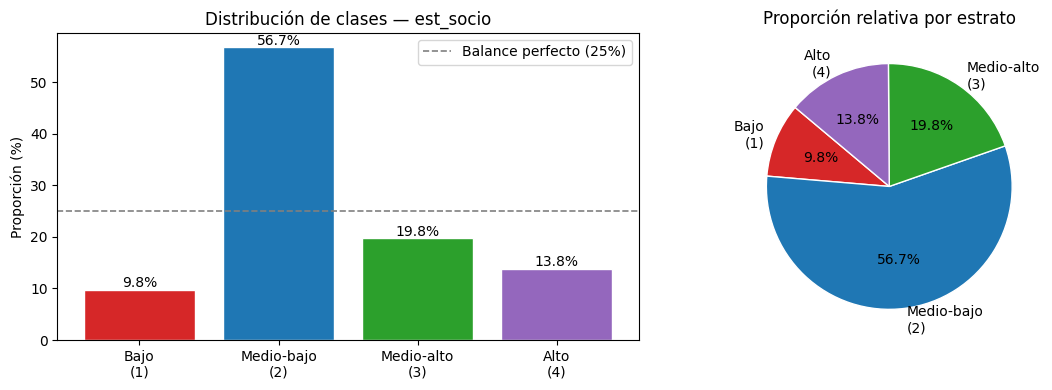

In [75]:
# ── Balance de clases ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

conteo = df['est_socio'].value_counts().sort_index()
proporcion = df['est_socio'].value_counts(normalize=True).sort_index() * 100

# Gráfica
etiquetas = ["Bajo\n(1)", "Medio-bajo\n(2)", "Medio-alto\n(3)", "Alto\n(4)"]
colores   = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras de proporción
bars = axes[0].bar(etiquetas, proporcion.values, color=colores, edgecolor='white')
axes[0].axhline(25, linestyle='--', color='gray', linewidth=1.2, label='Balance perfecto (25%)')
axes[0].set_ylabel("Proporción (%)")
axes[0].set_title("Distribución de clases — est_socio")
axes[0].legend()
for bar, val in zip(bars, proporcion.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha='center', fontsize=10)

# Pie chart
axes[1].pie(
    conteo.values, labels=etiquetas, colors=colores,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title("Proporción relativa por estrato")

plt.tight_layout()
plt.show()

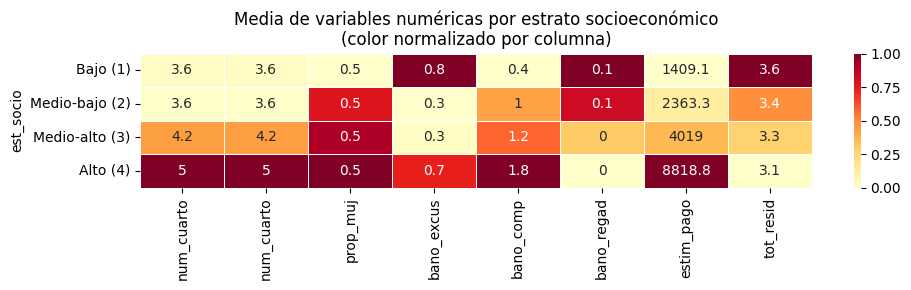

In [76]:
# ── Relación features–clase (heatmap de medias por estrato) ───────────────

num_cols = ['num_cuarto', 'num_cuarto', 'prop_muj',
            'bano_excus', 'bano_comp', 'bano_regad', 'estim_pago', 'tot_resid']

medias = df.groupby('est_socio')[num_cols].mean()

# Normalizar por columna para hacer comparables las escalas
medias_norm = (medias - medias.min()) / (medias.max() - medias.min())

import seaborn as sns
plt.figure(figsize=(10, 3))
sns.heatmap(medias_norm, annot=medias.round(1), fmt='g',
            cmap='YlOrRd', linewidths=0.5,
            yticklabels=["Bajo (1)", "Medio-bajo (2)", "Medio-alto (3)", "Alto (4)"])
plt.title("Media de variables numéricas por estrato socioeconómico\n(color normalizado por columna)")
plt.xlabel("")
plt.tight_layout()
plt.show()

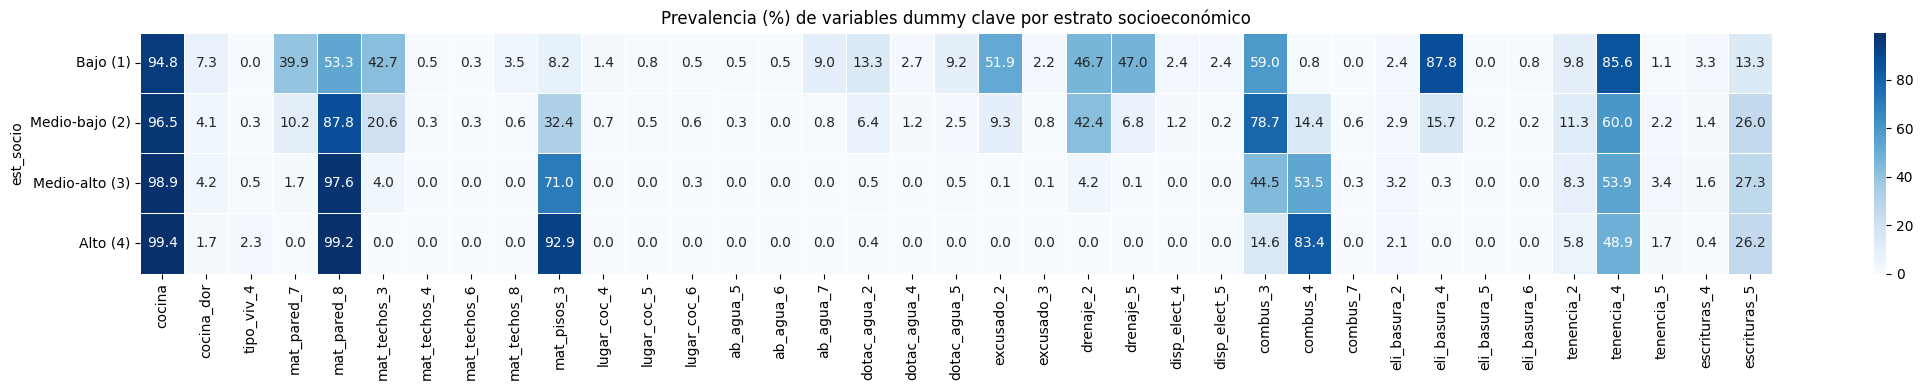

In [77]:
# ── Prevalencia de dummies por clase ─────────────────────────────────────
df_dum = df.drop(columns=num_cols)

prev = df_dum.groupby('est_socio').mean() * 100

plt.figure(figsize=(22, 4))
sns.heatmap(prev, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
            yticklabels=["Bajo (1)", "Medio-bajo (2)", "Medio-alto (3)", "Alto (4)"])
plt.title("Prevalencia (%) de variables dummy clave por estrato socioeconómico")
plt.tight_layout()
plt.show()

Con base en el diccionario de datos de ENIGH y en la estructura final de la base utilizada en este proyecto, el conjunto de datos contiene **3767 observaciones** y **45 variables**: **43 enteras**, **2 de punto flotante** y **0 valores nulos**. En términos funcionales, la base puede interpretarse como la combinación de: **2 variables binarias originales codificadas por catálogo** (`cocina`, `cocina_dor`), **7 variables numéricas o de conteo** (`num_cuarto`, `bano_comp`, `bano_excus`, `bano_regad`, `estim_pago`, `tot_resid`, `prop_muj`), **35 variables dummy** derivadas de variables categóricas de vivienda y servicios, y **1 variable objetivo** (`est_socio`).

### 2.1 Significado de las variables numéricas y binarias originales

- **`cocina`**: indica si la vivienda cuenta con cocina. Es una variable categórica binaria del catálogo `si_no`, almacenada como entero.
- **`cocina_dor`**: indica si la cocina se utiliza también como dormitorio. También pertenece al catálogo `si_no`.
- **`num_cuarto`**: número total de cuartos de la vivienda.
- **`bano_comp`**: cantidad de baños completos, es decir, con excusado y regadera.
- **`bano_excus`**: cantidad de baños que cuentan únicamente con excusado.
- **`bano_regad`**: cantidad de baños que cuentan únicamente con regadera.
- **`estim_pago`**: estimación del pago de renta de la vivienda.
- **`tot_resid`**: total de residentes que habitan la vivienda.
- **`prop_muj`**: proporción de mujeres dentro del total de residentes; esta es una variable derivada a partir de la composición del hogar.
- **`est_socio`**: variable objetivo del modelo, correspondiente al estrato socioeconómico de la vivienda.

### 2.2 Significado de las variables dummy de la base final

Las siguientes variables son indicadores binarios que toman el valor 1 cuando la observación pertenece a la categoría codificada en el sufijo, y 0 en caso contrario:

- **`tipo_viv_4`**: categoría 4 del catálogo **tipo de vivienda** ([`tipo_viv`](\catalogos\tipo_viv.csv)).
- **`mat_pared_7`, `mat_pared_8`**: categorías 7 y 8 del catálogo **material de paredes** ([`mat_pared`](\catalogos\mat_pared.csv)).
- **`mat_techos_3`, `mat_techos_4`, `mat_techos_6`, `mat_techos_8`**: categorías 3, 4, 6 y 8 del catálogo **material de techos** ([`mat_techos`](\catalogos\mat_techos.csv)).
- **`mat_pisos_3`**: categoría 3 del catálogo **material de pisos** ([`mat_pisos`](\catalogos\mat_pisos.csv)).
- **`lugar_coc_4`, `lugar_coc_5`, `lugar_coc_6`**: categorías 4, 5 y 6 del catálogo **lugar donde cocinan** ([`lugar_coc`](\catalogos\lugar_coc).csv).
- **`ab_agua_5`, `ab_agua_6`, `ab_agua_7`**: categorías 5, 6 y 7 del catálogo **abastecimiento de agua** ([`ab_agua`](\catalogos\ab_agua.csv)).
- **`dotac_agua_2`, `dotac_agua_4`, `dotac_agua_5`**: categorías 2, 4 y 5 del catálogo **dotación de agua** ([`dotac_agua`](\catalogos\dotac_agua.csv)).
- **`excusado_2`, `excusado_3`**: categorías 2 y 3 del catálogo **tiene excusado** ([`excusado`](\catalogos\excusado.csv)).
- **`drenaje_2`, `drenaje_5`**: categorías 2 y 5 del catálogo **destino de drenaje** ([`drenaje`](\catalogos\drenaje.csv)).
- **`disp_elect_4`, `disp_elect_5`**: categorías 4 y 5 del catálogo **disponibilidad eléctrica** ([`disp_elect`](\catalogos\disp_elect.csv)).
- **`combus_3`, `combus_4`, `combus_7`**: categorías 3, 4 y 7 del catálogo **tipo de combustible** ([`combus`](\catalogos\combus.csv)).
- **`eli_basura_2`, `eli_basura_4`, `eli_basura_5`, `eli_basura_6`**: categorías 2, 4, 5 y 6 del catálogo **eliminación de basura** ([`eli_basura`](\catalogos\eli_basura.csv)).
- **`tenencia_2`, `tenencia_4`, `tenencia_5`**: categorías 2, 4 y 5 del catálogo **tipo de tenencia de la vivienda** ([`tenencia`](\catalogos\tenencia.csv)).
- **`escrituras_4`, `escrituras_5`**: categorías 4 y 5 del catálogo **escrituras de la vivienda** ([`escrituras`](\catalogos\escrituras.csv)). En la base final aparece una categoría con sufijo 5, lo que sugiere una recodificación o tratamiento previo adicional respecto al rango base del diccionario.

En conjunto, esta estructura indica que la base final ya no conserva todas las variables originales de ENIGH, sino una **selección transformada** orientada al modelado. Las variables de conteo y proporción aportan magnitudes directas del hogar, mientras que las dummies conservan información categórica sobre materiales, servicios básicos, saneamiento, tenencia y condiciones generales de la vivienda. Esto facilita el uso de algoritmos de clasificación, ya que todas las entradas quedan expresadas en formato numérico interpretable por el modelo.

### 2.3 Tipos de variables disponibles y su posible relación con `est_socio`

| Grupo | Variables | Tipo | Posible relación con la salida |
|---|---|---|---|
| Binarias originales codificadas por catálogo | `cocina`, `cocina_dor` | Enteras categóricas binarias (codificadas con claves 1–2) | La presencia de cocina y, sobre todo, el uso de la cocina como dormitorio pueden reflejar condiciones de hacinamiento o menor calidad habitacional, por lo que potencialmente ayudan a distinguir estratos bajos de altos. |
| Variables de conteo de infraestructura | `num_cuarto`, `bano_comp`, `bano_excus`, `bano_regad`, `tot_resid` | Enteras discretas | Un mayor número de cuartos y de baños completos suele asociarse con mejores condiciones materiales y, por tanto, con estratos más altos. En cambio, una mayor cantidad de residentes por vivienda puede reflejar presión habitacional y relacionarse con estratos más bajos. |
| Variable económica continua | `estim_pago` | Continua (`float64`) | Es una de las variables con relación más directa con el nivel socioeconómico, ya que aproxima la capacidad de pago por vivienda o renta. En términos descriptivos, su media aumenta marcadamente conforme sube el estrato. |
| Variable demográfica derivada | `prop_muj` | Continua (`float64`) | Su relación con el estrato no parece fuerte ni monotónica en la exploración inicial, por lo que puede aportar información complementaria, aunque probablemente con menor poder discriminante que las variables de vivienda y servicios. |
| Dummies de tipo de vivienda y materiales | `tipo_viv_4`, `mat_pared_7`, `mat_pared_8`, `mat_techos_3`, `mat_techos_4`, `mat_techos_6`, `mat_techos_8`, `mat_pisos_3` | Binarias 0/1 | Estas variables capturan calidades estructurales de la vivienda. En general, ciertos materiales se concentran en estratos altos y otros en estratos bajos, por lo que son atributos muy relevantes para separar clases. |
| Dummies de cocina, agua y saneamiento | `lugar_coc_4`, `lugar_coc_5`, `lugar_coc_6`, `ab_agua_5`, `ab_agua_6`, `ab_agua_7`, `dotac_agua_2`, `dotac_agua_4`, `dotac_agua_5`, `excusado_2`, `excusado_3`, `drenaje_2`, `drenaje_5` | Binarias 0/1 | Reflejan acceso a servicios básicos y condiciones sanitarias. Este grupo suele ser altamente informativo porque la disponibilidad y calidad de agua, excusado y drenaje son variables muy asociadas al bienestar material del hogar. |
| Dummies de electricidad, combustible y manejo de residuos | `disp_elect_4`, `disp_elect_5`, `combus_3`, `combus_4`, `combus_7`, `eli_basura_2`, `eli_basura_4`, `eli_basura_5`, `eli_basura_6` | Binarias 0/1 | Permiten identificar diferencias de equipamiento e infraestructura doméstica. El tipo de combustible y la forma de eliminar la basura pueden funcionar como marcadores indirectos de urbanización, formalidad y calidad de servicios. |
| Dummies de tenencia y documentos de vivienda | `tenencia_2`, `tenencia_4`, `tenencia_5`, `escrituras_4`, `escrituras_5` | Binarias 0/1 | La forma de tenencia y la disponibilidad de escrituras pueden estar asociadas con estabilidad patrimonial, formalidad legal y consolidación de la vivienda, aspectos que suelen diferenciar estratos socioeconómicos. |

Adicionalmente, a partir del **heatmap de medias por estrato**, se observa que varias variables numéricas sí presentan un comportamiento coherente con la variable de salida. Por ejemplo, la media de **`estim_pago`** crece de manera muy marcada desde el estrato **Bajo (1409.1)** hasta el estrato **Alto (8818.8)**, lo que sugiere un alto valor discriminante. De forma similar, **`num_cuarto`** aumenta de **3.6** a **5.0** y **`bano_comp`** de **0.4** a **1.8**, mientras que **`tot_resid`** disminuye ligeramente de **3.6** a **3.1**, patrón compatible con mejores condiciones materiales y menor hacinamiento relativo en los estratos más altos.

Las variables dummy también muestran diferencias útiles entre clases. Por ejemplo, **`mat_pared_8`** pasa de **53.3%** en el estrato bajo a **99.2%** en el alto, y **`mat_pisos_3`** de **8.2%** a **92.9%**, lo que indica que ciertas categorías de materiales están fuertemente asociadas con niveles socioeconómicos específicos. En contraste, otras variables como **`combus_3`** o **`eli_basura_4`** tienen mayor presencia en estratos bajos o intermedios y prácticamente desaparecen en el estrato alto, por lo que pueden ayudar a identificar condiciones de rezago o menor acceso a infraestructura.

### 2.4 Discusión sobre el balance entre clases

La distribución de la variable objetivo **no está balanceada**. De acuerdo con la exploración realizada, la clase **Medio-bajo (2)** concentra aproximadamente **56.7%** de las observaciones, mientras que **Bajo (1)** representa **9.8%**, **Medio-alto (3)** **19.8%** y **Alto (4)** **13.8%**. Esto implica una desviación importante respecto a un escenario perfectamente balanceado de **25% por clase**.

Este desbalance puede influir directamente en el proceso de clasificación. En particular, un modelo podría tender a **favorecer la clase mayoritaria** y obtener una exactitud global aparentemente buena aun cuando falle en identificar adecuadamente las clases minoritarias, especialmente la clase **Bajo (1)**. Por ello, al evaluar modelos no basta con observar únicamente la **accuracy**; también conviene analizar métricas sensibles al desbalance, como **recall**, **precision** y **F1-macro**, así como la **matriz de confusión**.

---

## 3. Preparación y tratamiento de los datos

Para esta investigación se reutilizará la base de datos procesada en el [Proyecto Final - Unidad 1](base_ENIGH_lasso.csv). La metodología para la construcción de la base fue primero realizar una limpieza e imputación de datos donde se utilizó la mediana para variables numéricas y moda para variables categóricas. Posteriormente se codificaron a las variables categóricas como dummies booleanos. Finalmente, trataron outliers y se realizó la selección de características mediante Lasso (``LassoCV() ``en sklear).

---

## 4. Construcción y comparación de modelos


In [78]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["est_socio"])
y = df["est_socio"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

Se construyen cinco modelos de clasificación para predecir el estrato socioeconómico (`est_socio`). Todos siguen el mismo protocolo:

- **Validación cruzada estratificada** con `StratifiedKFold(n_splits=5)` sobre `X_train_val`.
- **Búsqueda de hiperparámetros** con `RandomizedSearchCV` (modelos con espacio amplio) o `GridSearchCV` (modelos con espacio reducido).
- **Métricas reportadas**: `accuracy`, `f1_macro` y `f1_weighted`.
- **Integración de AUC-ROC**: se incorpora la métrica **ROC-AUC multiclase** bajo el esquema **One-vs-Rest (OvR)**, ya que permite evaluar la capacidad discriminativa global del modelo aun bajo un escenario de desbalance entre clases.
- **Métrica de refit**: `f1_macro`, que penaliza por igual los errores en clases minoritarias y mayoritarias, siendo la más adecuada ante el desbalance documentado en la sección anterior (He & Garcia, 2009).
- **`class_weight='balanced'`** en los modelos que lo soportan para compensar el desbalance de clases.

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

from sklearn.pipeline               import Pipeline
from sklearn.preprocessing          import StandardScaler
from sklearn.model_selection        import StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics                import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Modelos
from sklearn.linear_model           import LogisticRegression
from sklearn.discriminant_analysis  import LinearDiscriminantAnalysis
from sklearn.ensemble               import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm                    import SVC
from sklearn.neural_network         import MLPClassifier

# ── Protocolo común
CV       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING  = ['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc_ovr']
REFIT    = 'f1_macro'
N_ITER   = 30
SEED     = 42

# Almacena resultados de todos los modelos
resumen = {}

def registrar(nombre, search_obj):
    """Extrae métricas CV del mejor estimador y las guarda en resumen."""
    res = search_obj.cv_results_
    idx = search_obj.best_index_
    resumen[nombre] = {
        'best_params'   : search_obj.best_params_,
        'accuracy_mean' : res['mean_test_accuracy'][idx],
        'accuracy_std'  : res['std_test_accuracy'][idx],
        'f1_macro_mean' : res['mean_test_f1_macro'][idx],
        'f1_macro_std'  : res['std_test_f1_macro'][idx],
        'f1_w_mean'     : res['mean_test_f1_weighted'][idx],
        'f1_w_std'      : res['std_test_f1_weighted'][idx],
        'auc_roc_mean'  : res['mean_test_roc_auc_ovr'][idx],
        'auc_roc_std'   : res['std_test_roc_auc_ovr'][idx],
        'estimator'     : search_obj.best_estimator_,
    }
    print(f"\n{'='*60}")
    print(f"  {nombre}")
    print(f"{'='*60}")
    print(f"  Mejores hiperparámetros : {search_obj.best_params_}")
    print(f"  Accuracy      (CV mean±std): {resumen[nombre]['accuracy_mean']:.4f} ± {resumen[nombre]['accuracy_std']:.4f}")
    print(f"  F1-macro      (CV mean±std): {resumen[nombre]['f1_macro_mean']:.4f} ± {resumen[nombre]['f1_macro_std']:.4f}")
    print(f"  F1-weighted   (CV mean±std): {resumen[nombre]['f1_w_mean']:.4f} ± {resumen[nombre]['f1_w_std']:.4f}")
    print(f"  AUC-ROC OvR   (CV mean±std): {resumen[nombre]['auc_roc_mean']:.4f} ± {resumen[nombre]['auc_roc_std']:.4f}")

### 4.1 Regresión Logística

La regresión logística generalizada a multiclase (estrategia `ovr` o `multinomial`) es un modelo lineal interpretable que estima la probabilidad de pertenencia a cada clase. Se utiliza `GridSearchCV` dado que el espacio de hiperparámetros es reducido y bien conocido. Se aplica `class_weight='balanced'` para compensar el desbalance de clases.

In [89]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED
    ))
])

param_grid_lr = {
    'clf__C'          : [0.01, 0.1, 1, 10, 100],
    'clf__penalty'    : ['l1', 'l2'],
    'clf__solver'     : ['saga'],
    'clf__multi_class': ['ovr', 'multinomial'],
}

search_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=CV,
    scoring=SCORING,
    refit=REFIT,
    n_jobs=-1,
    verbose=0
)

search_lr.fit(X_train_val, y_train_val)
registrar('Logistic Regression', search_lr)



  Logistic Regression
  Mejores hiperparámetros : {'clf__C': 10, 'clf__multi_class': 'ovr', 'clf__penalty': 'l1', 'clf__solver': 'saga'}
  Accuracy      (CV mean±std): 0.6592 ± 0.0118
  F1-macro      (CV mean±std): 0.6397 ± 0.0132
  F1-weighted   (CV mean±std): 0.6688 ± 0.0110
  AUC-ROC OvR   (CV mean±std): 0.8812 ± 0.0056


### 4.2 Linear Discriminant Analysis (LDA)

LDA busca proyecciones lineales que maximicen la separabilidad entre clases, asumiendo distribuciones gaussianas con covarianza compartida. Su espacio de hiperparámetros es pequeño, por lo que se utiliza `GridSearchCV`.

In [ ]:
pipe_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearDiscriminantAnalysis())
])

param_grid_lda = [
    {'clf__solver': ['svd'],           'clf__shrinkage': [None]},
    {'clf__solver': ['lsqr', 'eigen'], 'clf__shrinkage': [None, 'auto', 0.1, 0.5, 0.9]},
]

search_lda = GridSearchCV(
    pipe_lda,
    param_grid_lda,
    cv=CV,
    scoring=SCORING,
    refit=REFIT,
    n_jobs=-1,
    verbose=0
)

search_lda.fit(X_train_val, y_train_val)
registrar('LDA', search_lda)


  LDA
  Mejores hiperparámetros : {'clf__shrinkage': None, 'clf__solver': 'svd'}
  Accuracy      (CV mean±std): 0.6932 ± 0.0119
  F1-macro      (CV mean±std): 0.6401 ± 0.0156
  F1-weighted   (CV mean±std): 0.6901 ± 0.0098
  AUC-ROC OvR   (CV mean±std): 0.8790 ± 0.0087


### 4.3 Métodos de Ensamble — Random Forest y Gradient Boosting

Se evalúan dos métodos de ensamble:
- **Random Forest**: bagging de árboles de decisión con submuestreo de variables por nodo.
- **Gradient Boosting**: boosting secuencial que minimiza una función de pérdida multiclase.

Ambos tienen espacios de hiperparámetros amplios, por lo que se utiliza `RandomizedSearchCV`.

In [91]:
# ── Random Forest ──────────────────────────────────────────────
pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ))
])

param_dist_rf = {
    'clf__n_estimators'     : [100, 200, 300, 500],
    'clf__max_depth'        : [None, 5, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__max_features'     : ['sqrt', 'log2', 0.5],
}

search_rf = RandomizedSearchCV(
    pipe_rf,
    param_dist_rf,
    n_iter=N_ITER,
    cv=CV,
    scoring=SCORING,
    refit=REFIT,
    n_jobs=-1,
    verbose=0,
    random_state=SEED
)

search_rf.fit(X_train_val, y_train_val)
registrar('Random Forest', search_rf)


  Random Forest
  Mejores hiperparámetros : {'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 30}
  Accuracy      (CV mean±std): 0.6963 ± 0.0153
  F1-macro      (CV mean±std): 0.6612 ± 0.0174
  F1-weighted   (CV mean±std): 0.7026 ± 0.0146
  AUC-ROC OvR   (CV mean±std): 0.8908 ± 0.0088


In [92]:
# ── Gradient Boosting ──────────────────────────────────────────
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(random_state=SEED))
])

param_dist_gb = {
    'clf__n_estimators' : [100, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__max_depth'    : [3, 5, 7],
    'clf__subsample'    : [0.7, 0.8, 1.0],
    'clf__max_features' : ['sqrt', 'log2', None],
}

search_gb = RandomizedSearchCV(
    pipe_gb,
    param_dist_gb,
    n_iter=N_ITER,
    cv=CV,
    scoring=SCORING,
    refit=REFIT,
    n_jobs=-1,
    verbose=0,
    random_state=SEED
)

search_gb.fit(X_train_val, y_train_val)
registrar('Gradient Boosting', search_gb)


  Gradient Boosting
  Mejores hiperparámetros : {'clf__subsample': 0.7, 'clf__n_estimators': 100, 'clf__max_features': None, 'clf__max_depth': 5, 'clf__learning_rate': 0.05}
  Accuracy      (CV mean±std): 0.7276 ± 0.0051
  F1-macro      (CV mean±std): 0.6653 ± 0.0127
  F1-weighted   (CV mean±std): 0.7212 ± 0.0064
  AUC-ROC OvR   (CV mean±std): 0.8920 ± 0.0077


### 4.4 Support Vector Machines (SVM)

SVM busca el hiperplano de margen máximo en un espacio de características potencialmente de alta dimensión mediante el uso de kernels. Se utiliza `RandomizedSearchCV` dada la sensibilidad del modelo al kernel y al parámetro de regularización `C`.

In [96]:
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        class_weight='balanced',
        probability=True,
        random_state=SEED
    ))
])

param_dist_svm = {
    'clf__C'     : [0.1, 1, 10, 100, 1000],
    'clf__kernel': ['rbf', 'poly', 'sigmoid'],
    'clf__gamma' : ['scale', 'auto', 0.001, 0.01, 0.1],
    'clf__degree': [2, 3, 4],
}

search_svm = RandomizedSearchCV(
    pipe_svm,
    param_dist_svm,
    n_iter=N_ITER,
    cv=CV,
    scoring=SCORING,
    refit=REFIT,
    n_jobs=-1,
    verbose=0,
    random_state=SEED
)

search_svm.fit(X_train_val, y_train_val)
registrar('SVM', search_svm)


  SVM
  Mejores hiperparámetros : {'clf__kernel': 'rbf', 'clf__gamma': 'scale', 'clf__degree': 2, 'clf__C': 1}
  Accuracy      (CV mean±std): 0.6276 ± 0.0078
  F1-macro      (CV mean±std): 0.6215 ± 0.0077
  F1-weighted   (CV mean±std): 0.6404 ± 0.0081
  AUC-ROC OvR   (CV mean±std): 0.8828 ± 0.0089


### 4.5 Red Neuronal (MLP)

El Perceptrón Multicapa (MLP) aproxima funciones no lineales mediante capas ocultas con activaciones no lineales. Se utiliza `RandomizedSearchCV` dado el amplio espacio de arquitecturas y tasas de aprendizaje posibles.

In [97]:
pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        max_iter=500,
        early_stopping=True,
        random_state=SEED
    ))
])

param_dist_mlp = {
    'clf__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'clf__activation'        : ['relu', 'tanh'],
    'clf__alpha'             : [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.001, 0.01],
    'clf__batch_size'        : [32, 64, 'auto'],
}

search_mlp = RandomizedSearchCV(
    pipe_mlp,
    param_dist_mlp,
    n_iter=N_ITER,
    cv=CV,
    scoring=SCORING,
    refit=REFIT,
    n_jobs=-1,
    verbose=0,
    random_state=SEED
)

search_mlp.fit(X_train_val, y_train_val)
registrar('MLP (Red Neuronal)', search_mlp)


  MLP (Red Neuronal)
  Mejores hiperparámetros : {'clf__learning_rate_init': 0.01, 'clf__hidden_layer_sizes': (64, 32), 'clf__batch_size': 64, 'clf__alpha': 0.001, 'clf__activation': 'relu'}
  Accuracy      (CV mean±std): 0.7173 ± 0.0143
  F1-macro      (CV mean±std): 0.6488 ± 0.0243
  F1-weighted   (CV mean±std): 0.7088 ± 0.0136
  AUC-ROC OvR   (CV mean±std): 0.8872 ± 0.0074


### 4.6 Tabla comparativa de modelos

La siguiente tabla resume las métricas de validación cruzada (media ± desviación estándar sobre 5 pliegues) para cada modelo en su configuración óptima de hiperparámetros. El criterio principal de selección es **F1-macro**.


                      Accuracy (μ±σ)   F1-macro (μ±σ) F1-weighted (μ±σ)    AUC-ROC (μ±σ)
Modelo                                                                                  
Logistic Regression  0.6592 ± 0.0118  0.6397 ± 0.0132   0.6688 ± 0.0110  0.8812 ± 0.0056
LDA                  0.6932 ± 0.0119  0.6401 ± 0.0156   0.6901 ± 0.0098  0.8790 ± 0.0087
Random Forest        0.6963 ± 0.0153  0.6612 ± 0.0174   0.7026 ± 0.0146  0.8908 ± 0.0088
Gradient Boosting    0.7276 ± 0.0051  0.6653 ± 0.0127   0.7212 ± 0.0064  0.8920 ± 0.0077
SVM                  0.6276 ± 0.0078  0.6215 ± 0.0077   0.6404 ± 0.0081  0.8828 ± 0.0089
MLP (Red Neuronal)   0.7173 ± 0.0143  0.6488 ± 0.0243   0.7088 ± 0.0136  0.8872 ± 0.0074


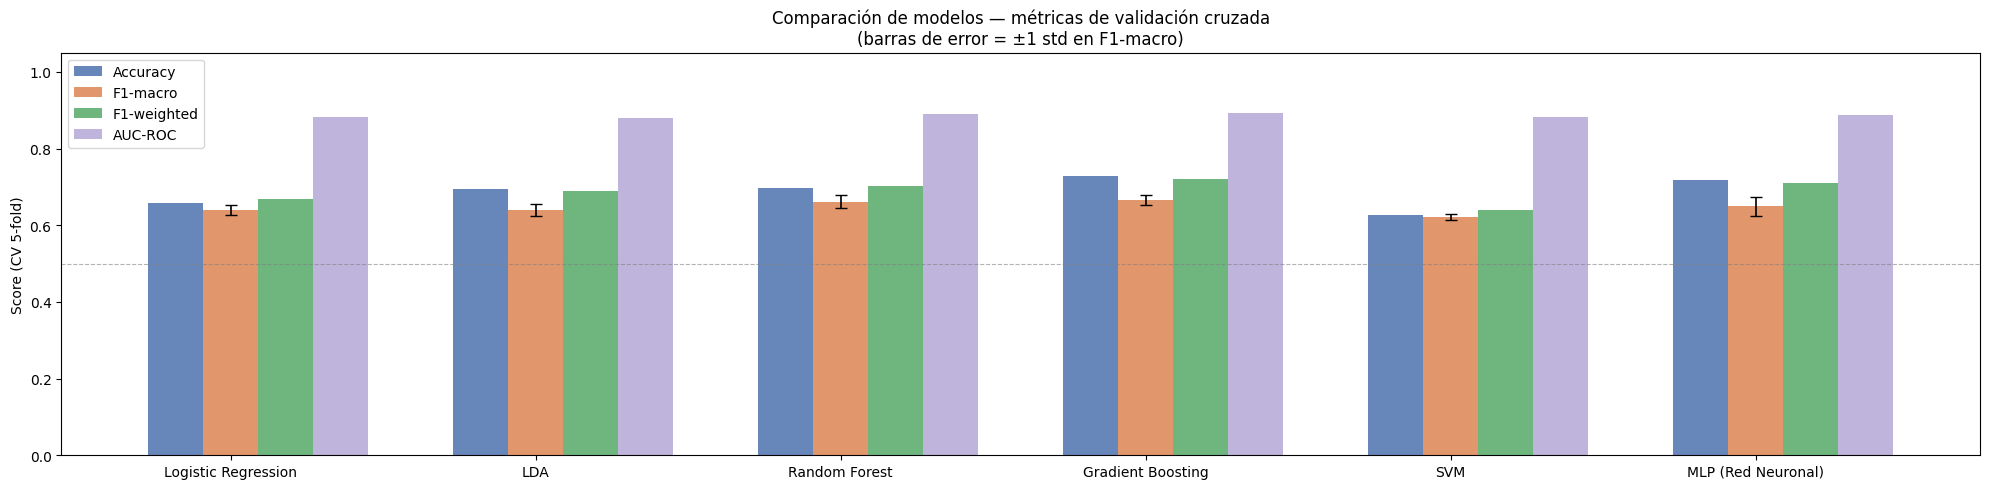


✓ Mejor modelo por F1-macro (CV): Gradient Boosting  (0.6653)


In [121]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
filas = []
for nombre, r in resumen.items():
    filas.append({
        'Modelo'            : nombre,
        'Accuracy (μ±σ)'   : f"{r['accuracy_mean']:.4f} ± {r['accuracy_std']:.4f}",
        'F1-macro (μ±σ)'   : f"{r['f1_macro_mean']:.4f} ± {r['f1_macro_std']:.4f}",
        'F1-weighted (μ±σ)': f"{r['f1_w_mean']:.4f} ± {r['f1_w_std']:.4f}",
        'AUC-ROC (μ±σ)': f"{r['auc_roc_mean']:.4f} ± {r['auc_roc_std']:.4f}",
    })

df_res = pd.DataFrame(filas).set_index('Modelo')
print(df_res.to_string())

# ── Gráfica comparativa ────────────────────────────────────────────────────────
nombres     = list(resumen.keys())
f1_macro_m  = [resumen[n]['f1_macro_mean']  for n in nombres]
f1_macro_s  = [resumen[n]['f1_macro_std']   for n in nombres]
acc_m       = [resumen[n]['accuracy_mean']  for n in nombres]
f1_w_m      = [resumen[n]['f1_w_mean']      for n in nombres]
auc_roc     = [resumen[n]['auc_roc_mean']   for n in nombres]

x     = np.arange(len(nombres))
width = 0.18
fig, ax = plt.subplots(figsize=(20, 5))

b1 = ax.bar(x - width, acc_m,      width, label='Accuracy',     color='#4C72B0', alpha=0.85)
b2 = ax.bar(x,          f1_macro_m, width, label='F1-macro',     color='#DD8452', alpha=0.85,
            yerr=f1_macro_s, capsize=4, error_kw={'elinewidth':1.2})
b3 = ax.bar(x + width,  f1_w_m,    width, label='F1-weighted',  color='#55A868', alpha=0.85)
b4 = ax.bar(x + width * 2,  auc_roc,    width, label='AUC-ROC',  color='#B4A7D6', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Comparación de modelos — métricas de validación cruzada\n(barras de error = ±1 std en F1-macro)')
ax.legend()
ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

# Destacar el mejor por F1-macro
mejor_modelo = max(resumen, key=lambda n: resumen[n]['f1_macro_mean'])
print(f"\n✓ Mejor modelo por F1-macro (CV): {mejor_modelo}  "      f"({resumen[mejor_modelo]['f1_macro_mean']:.4f})")



---

## 5. Selección del modelo final

A pesar de que las métricas de evaluación obtenidas para los **6 modelos** entrenados no muestran diferencias extremadamente amplias, sí se observa una tendencia consistente a favor de **Gradient Boosting**, el cual presenta el mejor desempeño global en validación cruzada. En particular, este modelo alcanzó el valor más alto de **Accuracy** $(0.7276 \pm 0.0051)$, **F1-macro** $(0.6653 \pm 0.0127)$, **F1-weighted** $(0.7212 \pm 0.0064)$ y **AUC-ROC** $(0.8920 \pm 0.0077)$. Esto es especialmente relevante porque la métrica **F1-macro** fue tomada como criterio principal de selección, al ser más apropiada en un problema con desbalance de clases, ya que evalúa el desempeño promedio entre clases sin favorecer excesivamente a la categoría mayoritaria. Adicionalmente es importante notar que dentro de los 6 modelos, el modelo basado en **Gradient Boosting** tiene en general una menor desviación sobre los promedios de sus métricas. 

Aunque modelos como **Random Forest** y **MLP** también mostraron resultados competitivos, sus valores quedaron ligeramente por debajo de Gradient Boosting en la métrica objetivo y en el comportamiento general. Por ejemplo, **Random Forest** obtuvo un **F1-macro de 0.6612**, mientras que **MLP** alcanzó **0.6488**, lo que indica que ambos son alternativas viables, pero no superiores. En contraste, el modelo **SVM** presentó el rendimiento más bajo en casi todas las métricas, especialmente en **Accuracy** y **F1-weighted**, por lo que no resulta la opción más conveniente para este conjunto de datos.

En consecuencia, se selecciona **Gradient Boosting como modelo final de clasificación**, ya que no solo obtuvo el mejor valor en la métrica prioritaria, sino que además mantuvo un desempeño sólido y estable en el resto de los indicadores. Esto sugiere que su capacidad de generalización es adecuada y que logra un mejor equilibrio entre discriminación global del problema y tratamiento del desbalance entre clases. Por tanto, desde una perspectiva comparativa y práctica, este modelo representa la alternativa más robusta para continuar con la etapa final del análisis.

---

## 6. Evaluación del desempeño del modelo

Mejores hiperparámetros encontrados:
{'clf__subsample': 0.7, 'clf__n_estimators': 100, 'clf__max_features': None, 'clf__max_depth': 5, 'clf__learning_rate': 0.05}

Desempeño en test:
            Métrica    Valor
           Accuracy 0.715548
           F1-macro 0.655515
        F1-weighted 0.711248
AUC-ROC OvR (macro) 0.895803

Classification report en test:
              precision    recall  f1-score   support

        Bajo     0.7234    0.6182    0.6667        55
  Medio-bajo     0.7849    0.8411    0.8120       321
  Medio-alto     0.4904    0.4554    0.4722       112
        Alto     0.7042    0.6410    0.6711        78

    accuracy                         0.7155       566
   macro avg     0.6757    0.6389    0.6555       566
weighted avg     0.7095    0.7155    0.7112       566



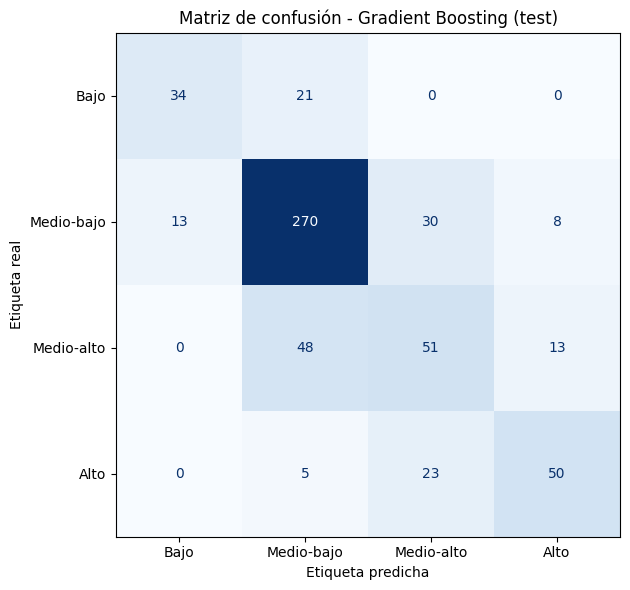

In [ ]:
# ── Evaluación final en test: Gradient Boosting ───────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 1) Mejor modelo encontrado en la búsqueda
best_gb = search_gb.best_estimator_

print("Mejores hiperparámetros encontrados:")
print(search_gb.best_params_)

# 2) Predicciones en test
y_pred = best_gb.predict(X_test)

# 3) Probabilidades para AUC-ROC multiclase
y_proba = best_gb.predict_proba(X_test)

# 4) Métricas de desempeño en test
acc_test       = accuracy_score(y_test, y_pred)
f1_macro_test  = f1_score(y_test, y_pred, average='macro')
f1_weight_test = f1_score(y_test, y_pred, average='weighted')

auc_roc_test = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr',
    average='macro'
)

# 5) Resumen numérico
res_test = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1-macro', 'F1-weighted', 'AUC-ROC OvR (macro)'],
    'Valor':   [acc_test, f1_macro_test, f1_weight_test, auc_roc_test]
})

print("\nDesempeño en test:")
print(res_test.to_string(index=False))

# 6) Nombres de clases
mapa_clases = {
    1: 'Bajo',
    2: 'Medio-bajo',
    3: 'Medio-alto',
    4: 'Alto'
}

# Orden real de clases aprendido por el modelo
classes = best_gb.classes_
labels_texto = [mapa_clases[c] for c in classes]

# 7) Reporte de clasificación por clase
print("\nClassification report en test:")
print(classification_report(
    y_test,
    y_pred,
    labels=classes,
    target_names=labels_texto,
    digits=4
))

# 8) Matriz de confusión con nombres en ejes
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=classes,
    display_labels=labels_texto,
    cmap='Blues',
    ax=ax,
    colorbar=False
)
ax.set_title('Matriz de confusión - Gradient Boosting (test)')
ax.set_xlabel('Etiqueta predicha')
ax.set_ylabel('Etiqueta real')
plt.tight_layout()
plt.show()

     Clase  AUC-ROC
      Bajo 0.972318
Medio-bajo 0.854460
Medio-alto 0.808439
      Alto 0.947995

AUC-ROC macro-promedio: 0.8967


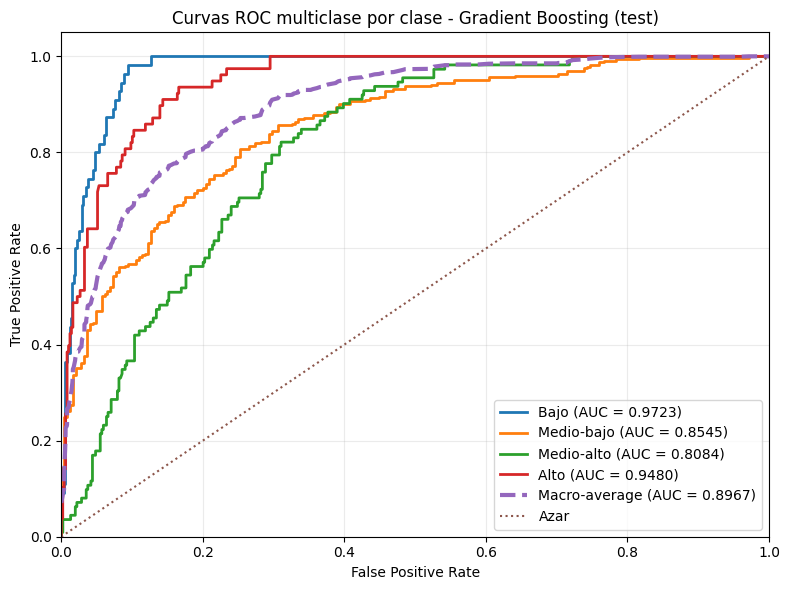

In [115]:
# ── Curvas ROC multiclase por clase con nombres correctos ─────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Probabilidades del mejor modelo
y_proba = best_gb.predict_proba(X_test)

# Clases reales aprendidas por el modelo
classes = np.array(best_gb.classes_)

# Ajusta este diccionario si tu codificación real fuera distinta
mapa_clases = {
    1: 'Bajo',
    2: 'Medio-bajo',
    3: 'Medio-alto',
    4: 'Alto'
}

# Nombres en el mismo orden de classes
class_names = [mapa_clases.get(c, f'Clase {c}') for c in classes]

# Binarizar etiquetas reales
y_test_bin = label_binarize(y_test, classes=classes)

# Seguridad para binario
if y_test_bin.ndim == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

# ROC y AUC por clase
fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(class_names):
    if np.unique(y_test_bin[:, i]).size < 2:
        print(f"Advertencia: la clase '{class_name}' no tiene suficientes ejemplos en y_test para calcular ROC.")
        continue

    fpr[class_name], tpr[class_name], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[class_name] = auc(fpr[class_name], tpr[class_name])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[c] for c in roc_auc.keys()]))
mean_tpr = np.zeros_like(all_fpr)

for c in roc_auc.keys():
    mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])

mean_tpr /= len(roc_auc)
fpr_macro = all_fpr
tpr_macro = mean_tpr
auc_macro = auc(fpr_macro, tpr_macro)

# Tabla de AUC por clase
df_auc = pd.DataFrame({
    'Clase': list(roc_auc.keys()),
    'AUC-ROC': list(roc_auc.values())
})
print(df_auc.to_string(index=False))
print(f"\nAUC-ROC macro-promedio: {auc_macro:.4f}")

# Gráfica
plt.figure(figsize=(8, 6))

for c in roc_auc.keys():
    plt.plot(
        fpr[c],
        tpr[c],
        linewidth=2,
        label=f'{c} (AUC = {roc_auc[c]:.4f})'
    )

plt.plot(
    fpr_macro,
    tpr_macro,
    linewidth=3,
    linestyle='--',
    label=f'Macro-average (AUC = {auc_macro:.4f})'
)

plt.plot([0, 1], [0, 1], linestyle=':', linewidth=1.5, label='Azar')

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC multiclase por clase - Gradient Boosting (test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

---

## 7. Conclusión y reflexión final

### 7.1 Aprendizajes

Este proyecto demostró que las características físicas, estructurales y de servicios de las viviendas, capturadas a través de la ENIGH 2024, contienen información suficiente para predecir el estrato socioeconómico de un hogar con una precisión razonable. Las variables con mayor poder discriminante son consistentes con lo esperado desde la teoría:

- **Variables económicas**: el pago estimado de renta (`estim_pago`) fue la más informativa, con una media que crece más de seis veces entre el estrato Bajo ($1,409) y el Alto ($8,819), lo que confirma que la capacidad de pago habitacional es un marcador directo del nivel socioeconómico.
- **Materiales de construcción**: dummies como `mat_pared_8` (paredes de material sólido, 53% en Bajo vs. 99% en Alto) y `mat_pisos_3` (pisos de materiales nobles, 8% en Bajo vs. 93% en Alto) son señales estructurales muy claras del nivel de vida.
- **Servicios básicos**: el acceso a agua entubada, drenaje conectado a la red pública, electricidad formal y recolección de basura diferencia marcadamente a los estratos, reflejando desigualdades en infraestructura urbana que persisten en México.
- **Tenencia y documentación**: la proporción de viviendas propias con escrituras crece con el estrato, conectando la formalización patrimonial con el bienestar económico.

En términos sustantivos, el análisis refuerza la idea de que en México la vivienda es un **espejo del bienestar del hogar**: sus materiales, servicios y costo reflejan las condiciones económicas de quienes la habitan con mayor fidelidad que muchas variables de ingreso autodeclaradas, que tienden a estar subreportadas en encuestas.

### 7.2 Modelo seleccionado

El **Gradient Boosting** se seleccionó como modelo final con base en evidencia cuantitativa y cualitativa:

1. **Mejor F1-macro en validación cruzada** (0.6653 ± 0.013): esta métrica fue el criterio de selección principal por ser la más adecuada ante el desbalance de clases documentado (He & Garcia, 2009).
2. **Mayor Accuracy** (0.7276) y **mayor F1-weighted** (0.7212) respecto a todos los demás modelos.
3. **Mayor AUC-ROC OvR** (0.8920), lo que indica mejor capacidad discriminativa global.
4. **Menor varianza**: la desviación estándar en las métricas de validación cruzada fue consistentemente menor que en Random Forest y MLP, sugiriendo mayor estabilidad al generalizar.
5. **Sin sobreajuste notable**: la diferencia entre el F1-macro en validación cruzada (0.6653) y en el conjunto de prueba independiente (0.6555) es mínima, lo que valida la capacidad de generalización del modelo.

El algoritmo de boosting secuencial resulta adecuado para este problema porque aprende progresivamente de los errores de iteraciones anteriores, lo que le permite capturar relaciones no lineales y sutiles entre variables como materiales de construcción, servicios públicos y capacidad económica, que son difíciles de modelar con métodos lineales como LDA o Regresión Logística.

### 7.3 Limitaciones

1. **Desbalance de clases persistente**: la clase Medio-bajo concentra el 56.7% de las observaciones. A pesar del uso de métricas robustas (F1-macro) y del protocolo de validación cruzada estratificada, el modelo muestra un sesgo hacia esta clase mayoritaria, especialmente en detrimento de Medio-alto (F1 = 0.47 en prueba).

2. **Dificultad de distinguir clases adyacentes**: las fronteras entre los estratos Medio-bajo y Medio-alto son borrosas por naturaleza. La misma AMAI reconoce que la clasificación socioeconómica es un continuo; la discretización en cuatro categorías introduce ambigüedad que ningún modelo puede resolver completamente con las variables disponibles.

3. **Reducción de dimensionalidad por Lasso**: la base utilizada ya pasó por una selección de características mediante `LassoCV`, lo que implica que se descartaron variables originales de la ENIGH que podrían haber aportado información complementaria. El modelo operó sobre 44 predictores de un conjunto original mucho más rico.

4. **Ausencia de variables de ingreso y educación**: la ENIGH incluye datos de ingreso, gasto, escolaridad y empleo que no fueron incorporados en la base final. En la práctica, estas variables son componentes clave de los índices de nivel socioeconómico (como el de la AMAI), y su exclusión limita el techo predictivo del modelo.

5. **Representatividad geográfica no explícita**: el modelo no considera la región o localidad como covariable, por lo que no captura diferencias regionales en el valor de los materiales o servicios (e.g., una vivienda con ciertos materiales puede implicar distinto nivel socioeconómico en una zona rural del sur que en una metrópolis del norte).

6. **Corte temporal único**: el análisis se basa en la ENIGH 2024, por lo que el modelo no puede capturar tendencias temporales ni adaptarse automáticamente a cambios estructurales en la distribución de estratos socioeconómicos de México.

### 7.4 Áreas de mejora

1. **Modelos más potentes de boosting**: explorar implementaciones como **XGBoost**, **LightGBM** o **CatBoost**, que ofrecen mayor eficiencia computacional y regularización más flexible, y suelen superar a `GradientBoostingClassifier` de scikit-learn en benchmarks comparables.

2. **Incorporación de variables adicionales**: utilizar la base completa de la ENIGH 2024 con variables de ingreso, gasto corriente monetario, escolaridad del jefe del hogar y características de empleo, que son ingredientes clave del índice AMAI y podrían reducir la confusión entre estratos adyacentes.

3. **Ensamblaje (*stacking*)**: combinar las predicciones de los mejores modelos individuales (Gradient Boosting, Random Forest, MLP) mediante un algún método de ensamble que aprenda a ponderar sus fortalezas relativas, potencialmente mejorando el F1-macro.

### 7.5 Conexión con la problemática original

El objetivo inicial fue explorar si las características de la vivienda y los servicios del hogar (información disponible públicamente a través de la ENIGH) permiten predecir el estrato socioeconómico de una familia mexicana. Los resultados confirman que **sí es posible con un nivel de precisión útil** (71.6% de accuracy, AUC-ROC ~0.90), aunque con limitaciones importantes para los estratos intermedios.

Desde una perspectiva de política pública, este tipo de modelos tiene valor práctico: ante la dificultad de medir el ingreso real de los hogares, la clasificación basada en características observables de la vivienda puede servir como proxy para priorizar programas sociales, focalizar apoyos o diseñar encuestas más eficientes. Sin embargo, cualquier aplicación real debería complementar este enfoque con validación local y considerar las limitaciones de equidad del modelo

---

## 8. Referencias

AMAI (n.d.). NSE 2021 / D-virtual. https://www.amai.org/NSE/index.php?queVeo=niveles

INEGI (n.d.). Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH) 2024. https://www.inegi.org.mx/programas/enigh/nc/2024/

He, H., & Garcia, E. A. (2009). Learning from imbalanced data. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284.